# **[LEPL1109] - STATISTICS AND DATA SCIENCES**
## **Hackathon 02 - Classifying and clustering images**
\
Prof. D. Hainaut\
Prod. L. Jacques\
\
\
Adrien Banse (adrien.banse@uclouvain.be)\
Jana Jovcheva (jana.jovcheva@uclouvain.be)\
François Lessage (francois.lessage@uclouvain.be)\
Valentin de Bassompierre (valentin.debassompierre@uclouvain.be)

![alt text](figures/hyperspectral.png)

<div class="alert alert-danger">
<b>[IMPORTANT] Read all the documentation.</b>  <br>
    Make sure that you read the whole notebook before completing it. The teaching team spent some time to introduce hyperlinks to useful external concepts (such as the description of a python object of function). Use them. If some concepts are unclear, you are also supposed to document by yourself while preparing the hackathon.
</div>

# **Guidelines and Deliverables**

*   This hackathon is due on the **19th of December at 23:59**. No extension will be given. 
*   This year, there is only one hackathon, which is therefore more substantial, but you have more time to complete it.
*   Copying code or answers from other groups (or from the internet) is strictly forbidden. <b>Each source of inspiration (stack overflow, git, other groups, ChatGPT...) must be clearly indicated!</b>
*  This notebook (with the "ipynb" extension) file and all other files that are necessary to run your code must be delivered on <b>Moodle</b>.
*  Only this notebook will be graded.
    * 2/20 if the codes executes well.
    * 18/20 for the answers to the questions. <br>

<div class="alert alert-warning">
<b>[NOTE] Use of generative AI</b>  <br>
    As mentioned above, plagiarism is forbidden. However, we cannot forbid you to use artificial intelligence BUT we remind you that the aim of this project is to learn on your own and with the help of the course material. Finally, we remind you that for the same question, artificial intelligence presents similar solutions, which could be perceived as a form of plagiarism. Be also aware that the teaching team checked the answers AI could provide to most of the hackathon questions; the results were disappointing and they do not reach the required level to succeed this hackathon.
</div>

# **Context & Objective**
Image analysis is widely used in areas ranging from environmental monitoring to computer vision. However, it is crucial to use the right tools to tackle different problems. Clustering and classification techniques such as **k-nearest neighbors (k-NN)** and **k-means** are foundational tools in data science, but **their effectiveness varies depending on the nature of the data**.

In this hackathon, you will be asked to explore the strengths and limitations of these methods are **3 distinct types of images dataset**: 

1. **Satellite RGB/RGBA images**: often used for land cover classification
2. **Dogs and cats RGB/RGBA images**: a classic benchmark in computer vision for object recognition and classification
3. **Hyperspectral satellite images**: high-dimensional data capturing information across multiple spectral bands, widely used in precision agriculture

Each dataset presents unique characteristics, such as dimensionality and feature correlation.

In this hackathon, your mission is to: 
- Apply k-NN and k-means to the first two datasets, and k-NN to the third dataset. 
- Evaluate the approaches for each dataset.
- Analyze why certain methods work better for certain types of images, linking your findings to the inherent properties of the datasets.

## **Notebook structure**

* PART I - Satellite images
   - I.1 - Pre-processing
   - I.2 - k-NN classification
   - I.3 - Classification using k-means
   - I.4 - PCA
    <br>
* PART II - Dogs and Cats
   - II.1 - Pre-processing
   - II.2 - k-NN classification
   - II.3 - PCA
   <br>
* PART III - Hyperspectral images
   - III.1 - Pre-processing
   - III.2 - k-NN classification
   - III.2 - k-NN classification with block-based sampling
   - 3.3 - KNN regressor

<div class="alert alert-warning">
<b>[NOTE] Divide to conquer</b>  <br>
This hackathon was designed so that it is possible to work on each dataset independently. <b>Take advantage of this aspect to divide the work between all team members!</b>
However, keep in mind that all the material in this hackathon will be relevant for the final exam, so every team member should make sure they understand all parts of the project.
</div>

## **External libraries**

To support you in completing this hackathon, we’ve listed some external libraries and functions that the teaching staff used to solve the tasks. Think of this as a helpful suggestion: you’re free to use other imports if you prefer. Just keep in mind that others have already faced similar challenges — so don’t spend too much time reinventing the wheel!

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import matplotlib.colors as mcolors
from skimage import io, transform
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy.stats import mode
from sklearn.decomposition import PCA
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
import sklearn
import nbformat
import plotly.io 

init_notebook_mode(connected=True)

<br><font size=7 color=#009999> <b>PART I - Satellite images</b> </font> <br><br>

In this part, you have a dataset containing satellite images, each of which figures one of four possible land types (green area, cloudy, water or desert). We refer to these land types as the "labels" of the images. The task at hand is to predict the label of each image, i.e. to which land type it corresponds.

![alt text](datasets/satellite/cloudy/train_12.jpg)
![alt text](datasets/satellite/desert/desert(1).jpg)
![alt text](datasets/satellite/cloudy/train_14.jpg)
![alt text](datasets/satellite/desert/desert(2).jpg)

# **Part I.1 - Pre-processing**

In this first part, you will be asked to pre-process the data. For this you are going to use the tools of the pandas toolbox and you are asked to produce a `pd.DataFrame` (read the doc [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) to understand this type of object) whose rows correspond to images, and whose columns contain 
- Either the [RGBA](https://en.wikipedia.org/wiki/RGBA_color_model) value of a pixel — the majority of columns
- Or the label of the image (cloud, desert, ...) — one such column

<div class="alert alert-warning">
<b>[NOTE] Pre-processing</b>  <br>
You should be careful about the following characteristics of the dataset: 
    
- The images are not necessarily of the same resolution
- Some images only contain [RGB](https://en.wikipedia.org/wiki/RGB_color_model) values, whereas others contain [RGBA](https://en.wikipedia.org/wiki/RGBA_color_model) values.
- Remove all images that contain `NaN` values.
</b>
</div>

In [ ]:
DATA_PATH = "datasets/satellite"      
LABEL_TO_IDX = {"cloudy": 0, "desert": 1, "green_area": 2, "water": 3}

# TO DO: fill the dataframe with the satellite images.
df = pd.DataFrame(...)

print(df.describe())

# **Part I.2 - k-NN classification**

You now have a dataset containing images with some pixels in [RGBA](https://en.wikipedia.org/wiki/RGBA_color_model) format, and each image is associated with a label (green area, cloudy, water and desert) indicating the class to which it belongs. The label is the category or class you will try to predict. The features (pixels) are the inputs used to learn how to predict the label. In this second part, you are asked to train a k-NN classifier on your dataset. In order to do this, first **split your dataset** in a training set containing 75% of the images, and a testing set containing 25% of it. Also, **scale** your dataset. 

<div class="alert alert-warning">
<b>[NOTE] Random seed</b>  <br>
    
In order to ensure the reproducibility of your results across different runs, set a [random seed](https://en.wikipedia.org/wiki/Random_seed) . 
</b>
</div>

<div class="alert alert-warning">
<b>[NOTE] Standardization</b>  <br>

In real-world datasets, different features are not on the same numerical scale: one variable may be expressed in meters, another in seconds, another in gray intensity, another in numbers, etc. If we directly introduce these raw features into algorithms such as k-NN or K-Means, which are based on distances, features with larger numerical ranges dominate the distance calculation, even though they are not more informative. Standardization solves this problem by placing all features on an equal footing, typically with a mean of 0 and a variance of 1.

Let $X \in \mathbb{R}^{N \times d}$ be your dataset, with $N$ datapoints and $d$ features (columns), it can be written as $X = (x^1 \dots x^d)$, with $x^i \in \mathbb{R}^N$. 

A column $x^i$ can be standardized if it is replaced by $z^i = (x^i - \mu^i) / \sigma^i$, with $\mu^i = \frac{1}{N}\sum_{j = 1}^N x^i_j$ and $\sigma^i = \sqrt{\frac{1}{N} \sum_{j = 1}^N (x_j^i - \mu^i)^2}$. 

A dataset is standardized if all its columns are standardized. 
</div>

In [ ]:
# TO DO: split your dataset into training and testing sets
x_train, x_test, y_train, y_test = ...

You will have to select a parameter `k`, the number of nearest neighbours. **Select the best parameter `k` between the following values: `[5, 10, 50, 100, 150, 200]`.**

<div class="alert alert-info">
<b>[QUESTION 1] Parameter selection</b>  <br>
    
- In order to choose the best <code>k</code> parameter, should you use the entire dataset or only the available data?
- How did you choose the best <code>k</code> parameter (which method did you use)?

Explain and justify. (Expected answer length: &le; 9 lines).
</div>

<div class="alert alert-success">
<b>[QUESTION 1] Answer</b>  <br>
**Insert your answer here.**
</b>
</div>

In [ ]:
# TO DO: find the best 'k' parameter
k = ...

Given the best `k`, **train a k-NN classifier** on your dataset. As seen in the course, use the `euclidean` distance between your points. 

In [ ]:
# TO DO: instantiate a k-NN classifier and train it on the satellite dataset
model = KNeighborsClassifier(...)
...

Now that you have a model, **evaluate it** in the following way: 
- Compute the accuracy of your model on your testing set.
- Plot the [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix).

In [ ]:
# TO DO: compute the accuracy on the testing set
accuracy = ...
print("The accuracy of the model is ", accuracy, "%")

In [ ]:
# TO DO: compute and plot the confusion matrix for the test set
cm = ...

<div class="alert alert-info">
<b>[QUESTION 2] Model evaluation</b>  <br>
    
- What can you say about the performance of your model?
- Is k-NN a good algorithm to classify these images?
- Why are some of the labels better classified than others? Give an intuitive explanation, and link it to the accuracy and confusion matrix.
    
(Expected answer length: &le; 9 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 2] Answer</b>  <br>
**Insert your answer here.**
</b>
</div>

We also ask you to produce a ROC curve to evaluate your classifier. In the course, we've seen how to do this for binary classification, i.e., when there are only two classes to differentiate. Here, there are more than two classes, and the method used must be adapted. In practice, there are several ways to do this, but here we ask you to use a One-vs-Rest strategy as explained in the link [here](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html). The idea is to compare each class against all the other classes considered as one, thus reverting to binary classification. Then, to evaluate the classifier as a whole, the results for each class can be averaged (see [here](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)).

We ask you to one **produce a multi-class ROC plot** containing: 
- A One-vs-Rest (OvR) ROC curve, for each class (4 curves)
- A ROC curve using the OvR micro-average (1 curve)
- A ROC curve using the OvR macro-average (1 curve)

On the plot, indicate the value of the area under the curve (AUC) for each curve.

In [ ]:
# TO DO: plot the multi-class ROC curves (in a single figure)
...

<div class="alert alert-info">
<b>[QUESTION 3] ROC Curve</b>  <br>

- Can you make the link between these ROC curves and the confusion matrix above?
- What is the difference between micro- and macro-average in this context?
- What information can you infer from the fact that both the micro- and macro-average curves are close to the upper left part of the figure?

(Expected answer length: &le; 12 lines).
</b>
</div>


<div class="alert alert-success">
<b>[QUESTION 3] Answer</b>  <br>
**Insert your answer here.**
</b>
</div>

# **Part I.3 - Classification using k-means**

In this third part, you are asked to cluster your dataset using the k-means algorithm. Even though K-Means is an unsupervised algorithm, it can still be informative and useful in a supervised learning setting. The key idea is that unsupervised structure can reveal information that helps classification. To do that, first **scale your dataset**. 

In [ ]:
# TO DO: Standardize your dataset
x_train_scaled = ...
x_test_scaled = ...

Now, **train a k-means clustering model**. Train it with `20` different centroid seeds. Again, make sure to set a [random seed](https://en.wikipedia.org/wiki/Random_seed) to ensure reproducibility. 

In [ ]:
# TO DO: instantiate a k-means clustering model and train it on the satellite dataset
kmeans = KMeans(...)

In order to transform a clustering model into a classifier, we need to assign each cluster to a label. To do that, use your training set and perform a **majority vote**. That means, assign each cluster to the label that is the most present in it. 

In [ ]:
# TO DO: assign a label to each cluster
...

<div class="alert alert-info">
<b>[QUESTION 4] Supervised or unsupervised?</b>  <br>
Is this way of using k-means supervised or unsupervised? Justify. (Expected answer length: &le; 3 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 4] Answer</b>  <br> 
**Insert your answer here.**
</b>
</div>

Now that you have a model, **evaluate it** in the following way: 
- Compute the accuracy of your model on your testing set using the assignment computed at the last step. 
- Plot the [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix).

In [ ]:
# TO DO: compute the accuracy on the testing set
accuracy = ...
print("The accuracy of the model is ", accuracy, "%")

In [ ]:
# TO DO: compute and plot the confusion matrix for the test set
cm = ...

# **Part I.4 - PCA**

In order to interpret the results above, we will try to visualize the dataset. **Reduce the dimensionality** of the entire dataset to 3 dimensions using **Principal Component Analysis (PCA)**. You can restrict your analysis to the training set.

In [ ]:
# TO DO: use PCA on the dataset
x_train_reduced = ...

<div class="alert alert-info">
<b>[QUESTION 5] PCA</b>  <br>
    
- Why is it important to standardize the dataset before applying a PCA?
- Should you compute the eigenvectors of the **covariance** or the **correlation**?
    
In your answer, include an explanation in the context of this very dataset, i.e. $(R, G, B, A)$ images. (Expected answer length: &le; 7 lines).

</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 5] Answer</b>  <br>
**Insert your answer here.**
</b>
</div>

**Make a 3D plot** of the reduced dataset. 

In [ ]:
# TO DO: Make a 3D plot of the reduced dataset.

<div class="alert alert-info">
<b>[QUESTION 6] Interpretation of k-means results</b>  <br>

- Interpret the results of the k-means clustering algorithm. Make the link between these results and the 3D plot above. 
- Is it a good idea to use k-means here?

(Expected answer length: &le; 9 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 6] Answer</b>  <br>
**Insert your answer here.**
</b>
</div>

<br><font size=7 color=#009999> <b>PART II - Dogs and Cats</b> </font> <br><br>

<img src="datasets/cats_and_dogs/dogs/dog_0.jpg" alt="Drawing" style="width: 400px;"/> <img src="datasets/cats_and_dogs/cats/cat_3.jpg" alt="Drawing" style="width: 400px;"/>

In this second part, we will try to use similar methods for the classification of **pictures of dogs and cats**. In particular, we will
- Pre-process the dataset
- Train a k-NN classifier, and evaluate it
- Use PCA to visualize the dataset

Then, we will compare how these methods perform compared to the first dataset. 

# **Part II.1 - Pre-processing**

**Pre-process the dataset** in the same fashion as the first dataset. That is, produce a `pd.DataFrame` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)) whose rows correspond to images, and whose columns contain either the RGBA value of a pixel or the label of the image.

In [8]:
# TO DO: fill the dataframe with the Cats&Dogs images

DATA_PATH = "datasets/cats_and_dogs"
LABEL_TO_IDX = {"cats": 0, "dogs": 1}


# on extrait toutes les images de chat et de chien pour les mettre dans un tableau
cat_images = io.imread_collection("datasets/cats_and_dogs/cats/*.jpg")
dog_images = io.imread_collection("datasets/cats_and_dogs/dogs/*.jpg")


# dimensions pour toutes les images
minx=32
miny=32

# création des titres des colonnes
def rgb(i):
    if i%3==0:
        return "R"
    elif i%3==1:
        return "G"
    else:
        return "B"
pixels = ["pixel"+str((i//3)+1)+rgb(i) for i in range(0,minx*miny*3)]

# ajoute aux colonnes une colonne qui contient une valeur binaire correspondant à un chat ou à un chien
# ici les chats ont le label=0 et les chiens label=1
pixels.insert(0,"label")

# on redimensionne les images aux dimensions souhaitées et on normalise les données
cat_images_resized=[]
for img in cat_images:
    # les données sont normalisées par défaut
    cat_images_resized.append(np.insert(np.ravel(transform.resize(img,(minx,miny))), 0, 0))
# l'argument preserve_range=True permet de ne pas normaliser les données

dog_images_resized=[]
for img in dog_images:
    # les données sont normalisées par défault
    dog_images_resized.append(np.insert(np.ravel(transform.resize(img,(minx,miny))), 0, 1))

# création du dataframe, les lignes représentent les images et les colonnes représentent les pixels et le label
df = pd.DataFrame(columns=pixels,data=cat_images_resized+dog_images_resized)

# on retire les lignes contenant des données corrompus
df = df.dropna()

# Séparer les features (X) et labels (y)
X = df.drop(columns="label").values
y = df["label"].values

# résumé du dataframe
print(df.describe())

            label     pixel1R     pixel1G     pixel1B     pixel2R     pixel2G  \
count  696.000000  696.000000  696.000000  696.000000  696.000000  696.000000   
mean     0.498563    0.581293    0.583510    0.531337    0.586162    0.587203   
std      0.500358    0.315929    0.307995    0.342020    0.315520    0.306982   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.304253    0.310846    0.205157    0.306838    0.322608   
50%      0.000000    0.619049    0.611429    0.528630    0.633464    0.625095   
75%      1.000000    0.884574    0.862514    0.871573    0.887462    0.860693   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

          pixel2B     pixel3R     pixel3G     pixel3B  ...  pixel1021B  \
count  696.000000  696.000000  696.000000  696.000000  ...  696.000000   
mean     0.536654    0.588320    0.588668    0.537977  ...    0.526910   
std      0.340444    0.312663    0.304394    0.3

### commenatire sur le code

Nous redimensionnons toutes les images à une taille uniforme de 32x32 pixels afin faciliter d'éliminer la redondance d'information pour le KNN.
Le redimensionnemment des images permet également de représenter chaque image par un vecteur de même longueur.
Chaque ligne du DataFrame correspond à une image, la première colonne, "label", indique la classe de l'image : 0 pour les chats, 1 pour les chiens. Chaque colonne correspond à une valeur de pixel pour une couleur spécifique (R, G ou B).

Finalement, X contient toutes les valeurs des pixels (les features) pour chaque image, y contient les labels associés à chaque image (0 pour chat, 1 pour chien) et ces deux tableaux serviront pour l’entraînement d’algorithmes de classification.

Le temps de compilation est assez long (≃4min)

# **Part II.2 - k-NN classification**

**Train a k-NN classifier** in the same fashion as for the first dataset. 

The maximum mean accuracy is 57.461459% for k= 10


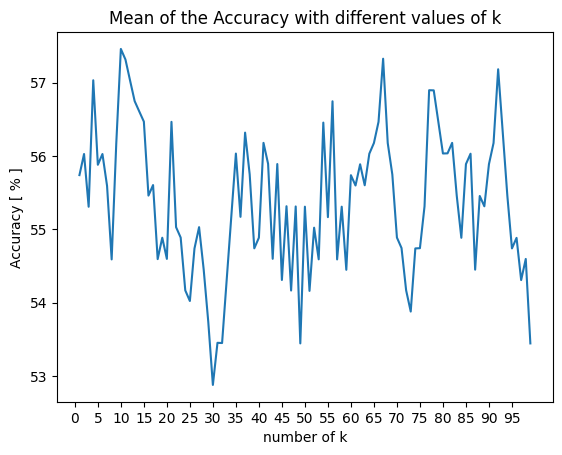

In [9]:
# TO DO: train a k-NN classifier on this dataset

# on split le dataset, on prend 20% de ce dataset pour tester notre méthode et 80% pour l'entrainer ,
# on prend le même nombre d'image chat et chien dans chaque nouveau dataset (train et test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# on cherche le k tel que l'accuracy est la meilleure pour différent split du dataset donc on aura pas forcément le meilleur k pour
# notre split an particulier
# pour cela on test pour k allant de 1 à 100
param = {"n_neighbors": list(range(1,100))}
# on souhaite avoir la meilleure accuracy possible , dont c'est notre score
grid =GridSearchCV(KNeighborsClassifier(),param_grid=param,scoring="accuracy",n_jobs=-1)
grid.fit(X,y)
print("The maximum mean accuracy is %02f%% for k= %d"%((grid.best_score_ )*100,grid.best_params_["n_neighbors"]))

# graphe de l'accuracy moyenne en fonction du k 
accuracy =grid.cv_results_['mean_test_score']
k100=grid.cv_results_['param_n_neighbors']
plt.xlabel("number of k")
plt.ylabel("Accuracy [ % ]")
plt.plot(k100,accuracy*100)
plt.xticks(np.arange(0, 100, 5))
plt.title("Mean of the Accuracy with different values of k")
plt.show()
 
# on prend le k optimal et on crée note knn classifier avec cette valeur
k=grid.best_params_["n_neighbors"]
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

## explication du code
On commence par mettre diviser le dataset en 2 dataset, un pour pour l'entrainement du modèle et un autre pour tester la fiabilité du modèle.
Ensuite on choisit notre hyperparamètre k (nombre de voisin ) en fonction de l'accuracy (en fonction une cross-validaed-grid-search).
Notre méthode de division fait en sorte d'avoir le même ratio d'images chien/chat dans les 2 dataset.
Le graphique montre l'évolution de l'accuracy (moyenne calculé pour diffrent split de dataset) en fonction de k.
On obtient un k optimal de 10.

**Evaluate your k-NN classifier** by 
- Computing the accuracy
- Plotting the Confusion Matrix
- Plotting the ROC Curve

In [10]:
# TO DO: compute the accuracy on the test set

accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is ", accuracy*100, "%")

The accuracy of the model is  55.00000000000001 %


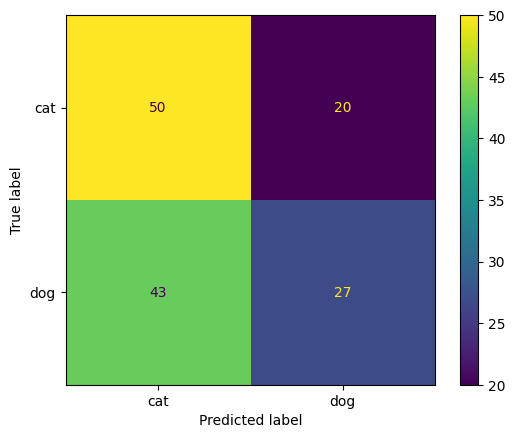

In [11]:
# TO DO: compute and plot the confusion matrix for the test set
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])

disp.plot()
plt.show()

## Commenataire sur l'image
On constate que notre modèle contient une grande quantité d'images mal classé. 


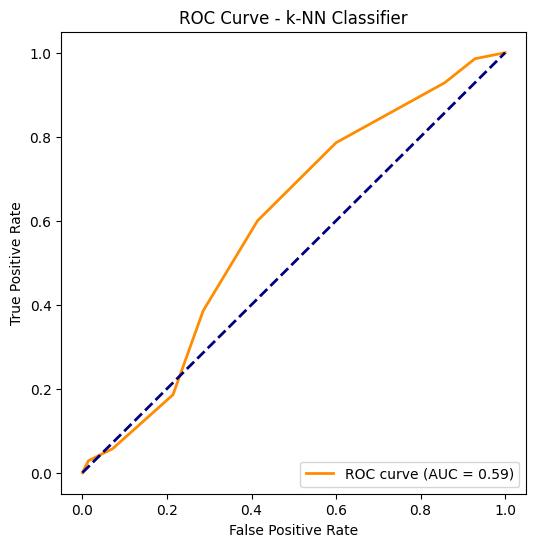

In [12]:
# TO DO: plot the ROC curve of your k-NN classifier

# 1 Encoder les labels en binaire
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)  # chat=0, dog=1

# 2 Obtenir les probabilités de la classe positive
y_score = knn.predict_proba(X_test)[:,1]  # probabilité de "dog"

# 3 Calculer FPR, TPR et AUC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

# 4 Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - k-NN Classifier")
plt.legend(loc="lower right")


plt.show()

## commentaire
On constate que la courbe de ROC est assez proche d'un de la droite x=y (modèle aléatoire) , par conséquent l'AUC est assez faible ≃ 60%.
Cela correspond bien au résultat de la matrice de confusion.

# **Part II.3 - PCA**

In order to have further insight about this dataset, **reduce the dimension** of the dataset to 3 dimensions using **Principal Component Analysis (PCA)**. Again, your analysis can be restricted to the training set. 

In [13]:
# TO DO: use PCA on the dataset
# x_train_reduced = ...

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA sur 3 composantes principales
pca = PCA(n_components=3)
X_pca_3 = pca.fit_transform(X_scaled)


# Conversion en DataFrame
df_pca3 = pd.DataFrame({
    "PC1": X_pca_3[:,0],
    "PC2": X_pca_3[:,1],
    "PC3": X_pca_3[:,2],
    "Label": y
})

Make the same 3D plot as above. 

In [ ]:
# TO DO: make a 3D plot of the reduced dataset.
# Visualisation interactive 3D
import sys
print(sys.executable)

fig = px.scatter_3d(
    df_pca3,
    x="PC1", y="PC2", z="PC3",
    color=df_pca3["Label"].map({0: "Cat", 1: "Dog"}),
    title="PCA en 3D - Cats vs Dogs",
    opacity=0.7
)



fig.update_traces(marker=dict(size=3))
fig.show()

NameError: name 'px' is not defined

On constate ici que les 2 classes d'images sont très proches les unes des autres, il n'y a pas de cluster visible et donc cela rend la méthode de knn inutilisable

<div class="alert alert-info">
<b>[QUESTION 7] Analysis of the results on this dataset</b>  <br>
Is there a difference of performance between the k-NN trained on the first dataset (satellite image) and the second dataset (cats and dogs)? If so, highlight the main visual difference between the appearance of the images of the first and second datasets that could explain such a difference in performance and the difficulty level of the considered classification problem. Be precise, and make the link between your explanation and the accuracy, confusion matrix, ROC curve and PCA plot. (Expected answer length: &le; 9 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 7] Answer</b>  <br>
On observe bien une différence entre les performances de la partie I et de la partie II, cette différence est même très significative.(≃95% de précision pour point 1 contre ≃60% pour le point 2). Pour le premier dataset on doit determiner si l'image représente une zone verte, de l'eau, un desert ou des nuages . Toutes ces différentes catégories possèdent des couleurs paticulières,les images ont une couleur uniforme mais avec des tons de cette couleur différente.Pour le second dataset on doit determiner si l'image représente un chat ou un chien , sauf que les chats et chiens n'ont pas de couleurs particulières c'est à dire qu'un chien peut avoir la même couleur qu'un chat et inversément.Le fait que les deux classes que l'ont veut déterminer du deuxième dataset n'ont pas de couleurs caractéristiques rend la méthode k-nn très peu éfficace pour déterminer à que classe appartient l'image. 
</b>
</div>


<br><font size=7 color=#009999> <b>PART III - Hyperspectral images</b> </font> <br><br>

<img src="figures/salinas_1.png" alt="Drawing" style="width: 400px;"/> <img src="figures/salinas_2.png" alt="Drawing" style="width: 400px;"/>

We will now train and test our model on a hyperspectral image collected by the AVIRIS sensor over Salinas Valley, California.
This dataset is a classic benchmark in remote sensing, containing agricultural fields with 16 labeled classes, including vegetables, bare soil, and vineyards. The raw image has 224 spectral bands, of which 20 noisy water-absorption bands have been removed, leaving **204 effective bands**. The final image has a spatial resolution of **512 lines × 217 samples**.

Unlike ordinary RGB images, which record only three broad color channels (red, green, blue), hyperspectral images capture **hundreds of narrow spectral bands**, each corresponding to a specific wavelength. This fine spectral resolution reveals subtle material and chemical differences that ordinary color cannot.

To visualize this structure, consider the hyperspectral cube below.
Each pixel $(x,y)$ in the spatial plane contains an entire spectrum across wavelengths $\lambda$. 
The curve on the right illustrates this spectral signature, which quantifies how that pixel reflects or absorbs light across the electromagnetic spectrum.

We invite you to spend a few minutes to learn more about the [Salinas dataset](https://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes).

<img src="figures/HSI_diagram.png" alt="Drawing" style="width: 400px;"/>

# **Part III.1 - Pre-processing**

With RGB/RGBA images, we had multiple separate images, each with a single label (e.g., "dog" or "cat").

With the hyperspectral image, you have one large image: **you’ll crop it into smaller spatial patches** (e.g. groups of pixels), **split the collection of these patches into training and testing sets**, and **classify each patch based on its spectral signature**. The key difference is that you’re working with spatial regions of a single image rather than independent images.

For the hyperspectral image, you are given:

- A single large image (`img`) with height `H`, width `W`, and `B` spectral bands.
- A corresponding ground truth label map (`gt`) of the same height and width, where each pixel’s value indicates its class (e.g., 1 for forest, 2 for water, etc.), and 0 means background (to be ignored).

In [3]:
from scipy.io import loadmat

# Load data
data = loadmat('datasets/hyperspectral/hyperspectral.mat')
print(data)
gt_data = loadmat('datasets/hyperspectral/hyperspectral_gt.mat')

img = data['salinas_corrected']  # shape: H x W x B
gt = gt_data['salinas_gt']       # shape: H x W, 0 = background

H, W, B = img.shape

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:48:11 2011', '__version__': '1.0', '__globals__': [], 'salinas_corrected': array([[[290, 381, 585, ...,  36,  11,  17],
        [290, 381, 519, ...,  36,  11,  15],
        [290, 381, 585, ...,  30,  11,  11],
        ...,
        [373, 482, 594, ...,   6,   4,   0],
        [373, 482, 659, ...,   0,   0,   5],
        [305, 393, 655, ...,   1,   1,  -3]],

       [[379, 400, 600, ...,  32,  11,  15],
        [308, 400, 535, ...,  28,  15,  13],
        [379, 483, 535, ...,  26,   5,  15],
        ...,
        [376, 477, 590, ...,   3,   0,  -5],
        [376, 477, 590, ...,   7,   0,  13],
        [305, 393, 655, ...,   1,   1,  -3]],

       [[369, 495, 604, ...,  29,   9,  17],
        [298, 411, 604, ...,  23,   5,  13],
        [298, 411, 670, ...,  27,   7,  13],
        ...,
        [447, 468, 664, ...,   4,   7,   0],
        [305, 468, 664, ...,  14,   7,   2],
        [447, 384, 664, ...,   6, 

Your tasks are the following: 

1. Flatten the image cube into a 2D array of pixels. After flattening, each row of the array corresponds to one pixel, and each column represents a wavelength band. In other words, every row gives the spectral signature (intensity vs. wavelength) for one spatial location $(x,y)$ in the image cube. The above diagram of a hyperspectral cube may be helpful.

2. Flatten the label image in the same way so that each label matches the corresponding pixel.

3. Remove background pixels (where the label value is 0), keeping only labeled pixels.

4. Shuffle the remaining labeled pixels and split them into training (75%) and test (25%) sets.

In [4]:
flattend_image = img.reshape(H*W,B)
flattend_label = gt.reshape(H*W)

flattend_image_reduced = flattend_image[flattend_label != 0]
flattend_label_reduced = flattend_label[flattend_label != 0]


# Keep track of original flat indices of labeled pixels
labeled_flat_indices = np.where(flattend_label != 0)[0]    #renvoie un tuple dont le premier élément est le tableau des indices où la valeur est True

# ---- Train/test split using indices so we can visualize later ----
indices = np.arange(flattend_label_reduced.shape[0])  # flattend_label_reduced contient uniquement les labels non nuls; flattend_label_reduced.shape[0] renvoit le nombre d'élément qui ne contiennet des labels non nuls; puis arange construit un tableau crée un tableau : indices = [0, 1, 2, ..., N_labeled-1]

idx_train, idx_test, y_train, y_test = train_test_split( indices, flattend_label_reduced, test_size=0.25, random_state=0)   #tratify = flattend_label_reduced
#idx_train : les indices des pixels sélectionnés pour le train
#idx_test : les indices des pixels sélectionnés pour le test
#y_train : les labels correspondants au train

X_train = flattend_image_reduced[idx_train]  # -> on prend les lignes correspondant aux pixels de train
X_test  = flattend_image_reduced[idx_test]

# # TO DO: divide your dataset into training and testing sets, according to the methodology described above.
# X_train, X_test, y_train, y_test = train_test_split(flattend_image_reduced, flattend_label_reduced, test_size=0.25, random_state=0, stratify=flattend_label_reduced)

# **Part III.2 - k-NN classification**

**Train a k-NN classifier** with `k = 5` and the `euclidean` distance. Before training it, you should **normalize** the rows of your dataset.

<div class="alert alert-warning">
<b>[NOTE] Normalization</b>  <br>

Let $X \in \mathbb{R}^{N \times d}$ be your dataset, with $N$ data points and $d$ features (columns).  It can be written as $X = (x_1, \dots ,x_N)^\top$ where $x_i \in \mathbb{R}^d$.

A row $x_i$ can be normalized if it is replaced by $z_i = x_i / \|x_i\|$.  
A dataset is normalized if all its rows are normalized. 

</div>

<div class="alert alert-info">
<b>[QUESTION 8] Normalization</b>  <br>
In this example, when using the Euclidean distance, why is normalization important?  Explain your reasoning in terms of the spectral features of the pixels (their "shape" and "intensity").

<i>Hint:</i> The Euclidean distance is sensitive to the <b>magnitude</b> of the vectors. 

<i>Hint:</i> You may find it helpful to have another look at the spectral signature subplot of the hyperspectral cube diagram.

(Expected answer length: &le; 8 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 8] Answer</b>  <br>
C'est important de normaliser, pour que toutes les valeurs du spectre aient le même poids. 
</b>
</div>

In [5]:
# TO DO: normalize the rows of your dataset, and train a k-NN classifier on the training set
X_train_normalized = normalize(X_train, norm='l2')
X_test_normalized = normalize(X_test, norm='l2')

clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
clf.fit(X_train_normalized, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**Compute the accuracy** of your classifier. 

In [6]:
# TO DO: compute the accuracy of the classifier
y_pred = clf.predict(X_test_normalized)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is ", accuracy*100, "%")

The accuracy of the model is  93.09835217616197 %


**Visualize the train and test pixel locations on the ground truth map**. Color the testing pixels in green, the training pixels in red and the background in white. 

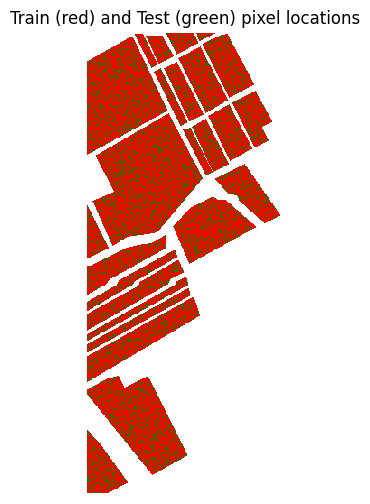

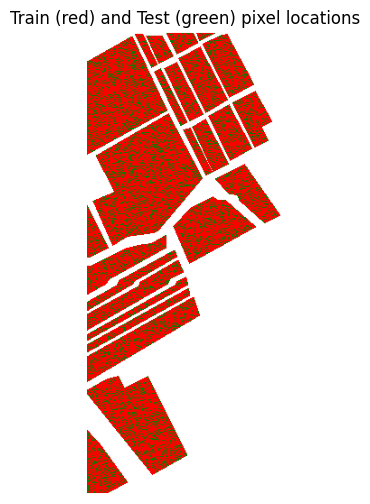

In [7]:
# 0 = background (white), 1 = train (red), 2 = test (green)
vis_flat = np.zeros(H * W, dtype=np.uint8)

# Map back from reduced index space to original flat pixel indices
train_flat_indices = labeled_flat_indices[idx_train]
test_flat_indices  = labeled_flat_indices[idx_test]

vis_flat[train_flat_indices] = 1
vis_flat[test_flat_indices]  = 2

vis_map = vis_flat.reshape(H, W)

cmap = mcolors.ListedColormap(['white', 'red', 'green'])

plt.figure(figsize=(6, 6))
plt.imshow(vis_map, cmap=cmap, interpolation='nearest')
plt.title('Train (red) and Test (green) pixel locations')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(vis_map, cmap=cmap)
plt.title('Train (red) and Test (green) pixel locations')
plt.axis('off')
plt.show()

<div class="alert alert-info">
<b>[QUESTION 9] Distribution of the training and testing</b>  <br>
    
- What do you notice about how the training and test pixels are distributed spatially?
- Knowing that this model should generalize to other hyperspectral images in the future, is this sampling strategy good? Justify.

(Expected answer length: &le; 5 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 9] Answer</b>  <br>
- loi des grands nombres , distribué uniformément -> donc d'office on aura assez de training donnée pour chaque label
- Comme distribution aléatoire des données de test et de train, évident que pour cette image, la "précision " est élevée
- Par contre pour d'autres images en particulier pour l'image où différentes zones ne sont pas séparés par des backgrounds et où les différentes zonnes ne sont pas séparés à ce point là , le modèle pourrait de venir très inéfficace.
-
</b>
</div>

# **Part III.3 - k-NN classification with block-based sampling**

This time, we will try a different approach. Instead of using the spectrum of each pixel, we will **divide the image into spatial blocks**, and use the center pixel of each block for classification. 

Your tasks are the following:

1. Extract patches of size 3x3 pixels. For each patch, only the center pixel is used for classification.
2. Skip background pixels (where gt == 0).
3. Collect the spectral vector of each center pixel, along with its label.
4. Split the data into training (75%) and testing (25%) sets. Be careful: make sure that the class distribution is preserved in both subsets (i.e., each class should appear in similar proportions in the training and testing sets).

In [8]:
X_list = []          # pour stocker les vecteurs spectraux des pixels centraux
y_list = []          # pour stocker les labels des pixels centraux
coords_list = []     # pour stocker les coordonnées (i, j) de chaque pixel central

# On parcourt seulement les pixels qui peuvent être le centre d'un patch 3x3
# donc on évite la bordure : i in [1, H-2], j in [1, W-2]
for i in range(1, H - 1,3):
    for j in range(1, W - 1,3):
        label = gt[i, j]
        if label != 0:  # on ignore le background
            spectrum = img[i, j, :]     # vecteur spectral du pixel central
            X_list.append(spectrum)
            y_list.append(label)
            coords_list.append((i, j))  # on garde la position pour la visualisation

# On convertit en tableaux numpy
X = np.array(X_list)           # shape: N x B
y = np.array(y_list)           # shape: N
coords = np.array(coords_list) # shape: N x 2

N = X.shape[0]
indices = np.arange(N)

idx_train, idx_test, y_train, y_test = train_test_split(indices, y, test_size=0.25, random_state=0, stratify=y)    # préserve la distribution des classes

# On récupère les données et les coordonnées correspondantes
X_train = X[idx_train]
X_test  = X[idx_test]

coords_train = coords[idx_train]   # (i, j) des pixels train
coords_test  = coords[idx_test]    # (i, j) des pixels test

# # TO DO: divide your dataset into training and testing sets, according to the methodology described above.
# X_train, y_train = ...
# X_test, y_test = ...

**Visualize the train and test pixel locations on the ground truth map**. Color the testing pixels in green, the training pixels in red and the background in white. 

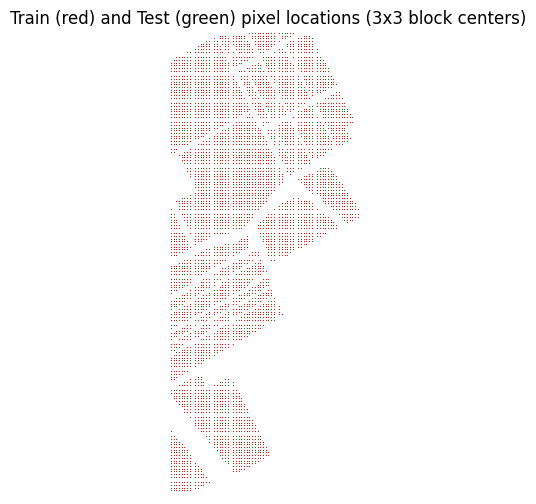

In [9]:
# TO DO: visualize the train/test pixel coordinates
# Carte de visualisation initialisée à 0 (background)
vis_map = np.zeros((H, W)) #dtype=np.uint8) apparemment on économise de la mémoire avec ça

# On place les pixels d'entraînement (1) et de test (2)
for (i, j) in coords_train:
    vis_map[i, j] = 1

for (i, j) in coords_test:
    vis_map[i, j] = 2

cmap = mcolors.ListedColormap(['white', 'red', 'green'])

plt.figure(figsize=(6, 6))
plt.imshow(vis_map, cmap=cmap, interpolation='nearest')
plt.title('Train (red) and Test (green) pixel locations (3x3 block centers)')
plt.axis('off')
plt.show()

**Train a k-NN classifier** with `k = 5` and the `euclidean` distance. Before training it, you should **normalize** the rows of your dataset.

In [10]:
# TO DO: normalize the rows of your dataset, and train a k-NN classifier on the training set
# Normalisation L2 des vecteurs spectraux
X_train_normalized = normalize(X_train, norm='l2')
X_test_normalized  = normalize(X_test, norm='l2')

# k-NN avec k=5 et distance euclidienne
clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
clf.fit(X_train_normalized, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**Compute the accuracy** of your model. 

In [ ]:
# TO DO: compute the accuracy of the classifier
y_pred = clf.predict(X_test_normalized)
accuracy = accuracy_score(y_test, y_pred) * 100

print("The accuracy of the model is ", accuracy, "%")

The accuracy of the model is  90.40639573617588 %


<div class="alert alert-info">
<b>[QUESTION 10] Block-based sampling</b>  <br>
Re-run your code using spatial blocks of 5×5 pixels, then 7×7.

- How does the accuracy change as the block size increases?
- Considering that the classifier should generalize to other hyperspectral images, do larger block sizes lead to better generalization?

(Expected answer length: &le; 5 lines).
</b>
</div>

<div class="alert alert-success">
<b>[QUESTION 10] Answer</b>  <br>
3x3 : accuracy: 90.40639573617588 %
5x5 : accuracy:  89.88970588235294 %
7x7 : accuracy:  84.75177304964538 %

- dans ce cas précis, on obtient une précision encore acceptable, car les zones de chaque label sont dispérsés en différents compartiments, cependant si on avait une autre image où les zones seraient plus mélangés, plus entre-mêlé, on obtiendrait sûrement une précision largement inférieure.
- La précision diminue de façon exp (graphe à faire) 
- Non, on ne devrait pas généraliser cette méthode

note : montrer que quand espace entre champs deviennent plus petits, cette méthode devient plus compliqué
</b>
</div>

# **Part IV - Conclusion**

<div class="alert alert-info">
<b>[QUESTION 11] Conclusion</b>  <br>
You must explain this project to an EPL student who has not taken the course using an illustration explaining the pre-processing to be implemented for these images (dimension management, RGB/RGB-A, etc.) and summarize one of the three parts (Satellite, dogs & cats or hyperspectral). You are free to create the illustration however you wish (as a slide or a diagram for example). It must only be included directly in this Jupyter notebook as an image or PDF file.
</b>
</div>


<div class="alert alert-success">
<b>[QUESTION 11] Answer</b>  <br>
<img src="conclusion1.png" alt="Drawing" style="width: 1500px;"/>

Pour faire nos explications, nous allons utiliser la partie I Satellite.
Pour pouvoir déterminer à quelle classe notre image appartient (pour notre exemple si elle représente un dessert, des nuages, des zones vertes ou encore de l'eau), il faut préprocesseur les données, c'est-à-dire qu'il faut préparer les données ici, nos images, pour pouvoir les utiliser pour entraîner un modèle et pour tester ces performances. Pour cela, il y a différentes étapes, premièrement on doit transformer les images en données exploitables par le code. Pour cela, on transforme les images en matrices de dimensions correspondant au nombre de pixels et contenant les valeurs des couleurs des pixels (images RGB) et aussi la transparence pour les images RGB-A. On met toutes les matrices d'images dans une même liste. Deuxièmement, pour ne pas utiliser trop de ressources et pour une question de performance, on redimensionne chaque image à des dimensions souhaitées. Troisièmement, notre dataset contient plusieurs types d'images RGB et RGB-A. Comme il faut qu'on ait un dataset avec le même type d'image, on ajoute une valeur "neutre" pour la valeur alpha des images RGB manquantes pour les transformer en image en notation RGB-A. Quatrièmement, on normalise les pixels pour ne pas avantager des pixels par rapport à d'autres. Finalement, on crée avec ce dataset un dataFrame, qui est une matrice donc chaque ligne représente une image et dont chaque colonne correspond à un pixel ou à un label, c'est-à-dire la classe à laquelle l'image appartient.

Après avoir fait le pre-processing sur notre dataset et obtenu notre dataframe on peut commencer à coder le modèle pour accomplir notre but qui est de déterminer ce que représente l'image. Pour cela, on va d'abord utiliser un modèle k-NN qui est une méthode qui classe les images en fonction de comment sont classées les images qui lui sont "proches"/ressemblent. Pour déterminer à quelle classe l'image appartient, on doit définir un hyperparamètre k qui va regarder les k voisins, images les plus ressemblantes/proches, et va donc définir à quelle classe l'image appartient en fonction de quelle classe la majorité des voisins appartiennent. Comme dit précédemment, il faut déterminer l'hyperparamètre k. Pour cela, on va utiliser la méthode kFold qui split notre data frame en plusieurs parties, une pour fixer le modèle et l'autre pour tester le modèle. En fonction des différents split de data frame, on obtient une valeur de k optimale.Après avoir trouvé notre k optimal, on peut trouver la matrice de confusion et tracer le graphe de la ROC. La matrice de confusion est une matrice, donc chaque ligne présente les vrais labels pour les images et les colonnes les labels pour les images prédites, et à chaque intersection on trouve le nombre d'images correspondant. Cette matrice nous permet donc de connaître le nombre d'images mal classées et "comment" elles sont mal classées.Le graphe ROC représente le taux de vrais positifs en fonction du taux de faux positifs, ce qui représente une qualité de prédiction du modèle.Ensuite, on implémente un modèle k-means qui est un modèle permettant de déterminer des clusters, pour cela le code fonctionne de manière dynamique, on choisit le centre d'un cluster arbitrairement, ensuite on prend tous les points les plus proches de ce centre du groupe appelé centroïde, ensuite on calcule le centroïde des clusters trouvés et ainsi de suite. Pour vérifier l'efficacité du modèle on utilise aussi la matrice de confusion. Finalement, on fait une PCA qui est une méthode permettant de diminuer le nombre de dimensions de notre dataframe c'est-à-dire utiliser moins de données par image, donc dans notre cas de pixels, tout en essayant de garder une précision correcte. Pour faire cela, on calque des valeurs propres qui représentent des variances et on garde les vecteurs propres liés aux plus grandes valeurs propres car une variance élevée donne beaucoup d'info .Après avoir réduit la dimension des données, on peut visualiser les données , aussi plus facilement que sans cette méthode car on peut maintenant représenter les données en 3D, ce qui est la dimension maximum à laquelle on visualise bien.
</b>
</div>